In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

import scipy.stats as stats

In [61]:
np.random.seed(42)

n = 300

Feature1 = np.random.normal(50,10,n)

Feature2 = np.random.normal(30,8,n)

Feature3 = np.random.normal(80,15,n)

noise = np.random.normal(0,5,n)

Target = (
    5
    + 2.5*Feature1
    - 1.8*Feature2
    + 3.2*Feature3
    + noise
)

df = pd.DataFrame({
    "Feature1":Feature1,
    "Feature2":Feature2,
    "Feature3":Feature3,
    "Target":Target
})

print(df.head())

    Feature1   Feature2    Feature3      Target
0  54.967142  23.368040   91.354829  394.534202
1  48.617357  25.518552   66.167520  290.379370
2  56.476885  35.978349   93.044089  379.315994
3  65.230299  34.882962  100.334568  432.749291
4  47.658466  29.832787   86.201524  347.247519


In [62]:
X = df.drop("Target",axis=1)

y = df["Target"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [64]:
y_pred = model.predict(X_test)

In [65]:
print("Intercept")

print(model.intercept_)

print()

print("Coefficients")

for name,coef in zip(X.columns,model.coef_):
    print(name,"=",coef)

Intercept
5.983967232647444

Coefficients
Feature1 = 2.5356910937821118
Feature2 = -1.833461699301603
Feature3 = 3.1870683862284412


# Linear Relationship

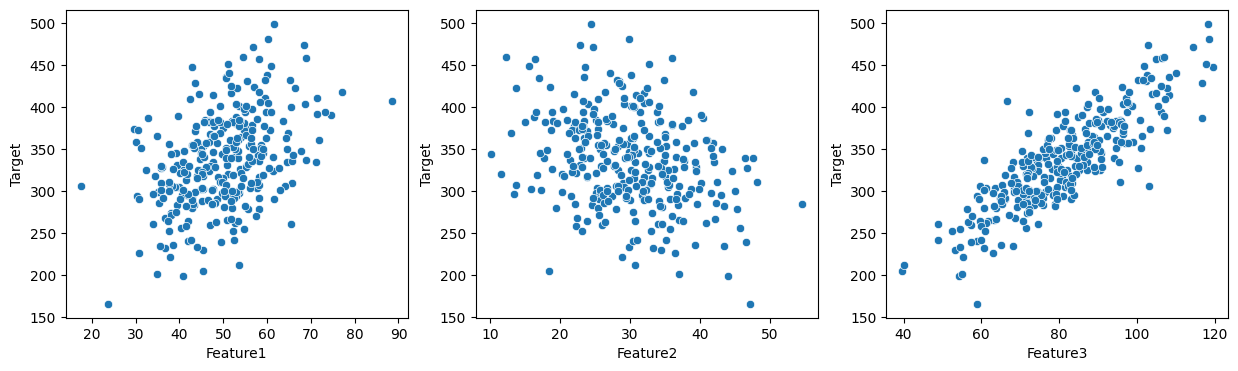

In [66]:
fig,ax=plt.subplots(1,3,figsize=(15,4))

sns.scatterplot(x=df["Feature1"],y=df["Target"],ax=ax[0])

sns.scatterplot(x=df["Feature2"],y=df["Target"],ax=ax[1])

sns.scatterplot(x=df["Feature3"],y=df["Target"],ax=ax[2])

plt.show()

# No Multicollinearity

In [67]:
vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values,i)
    for i in range(X.shape[1])
]

print(vif)

    Feature        VIF
0  Feature1  16.468434
1  Feature2  12.287617
2  Feature3  17.388455


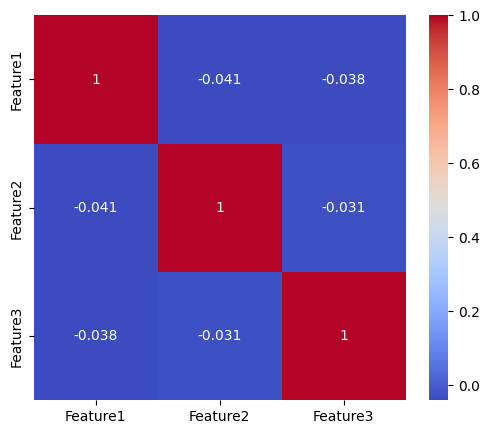

In [68]:
plt.figure(figsize=(6,5))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Residuals

In [70]:
residuals = y_test - y_pred
residuals

,Target
203,-1.743170
266,5.118454
152,1.529551
9,10.128554
233,1.296979
226,0.630807
196,-0.306844
109,-2.912967
5,-0.018935
175,-3.865404


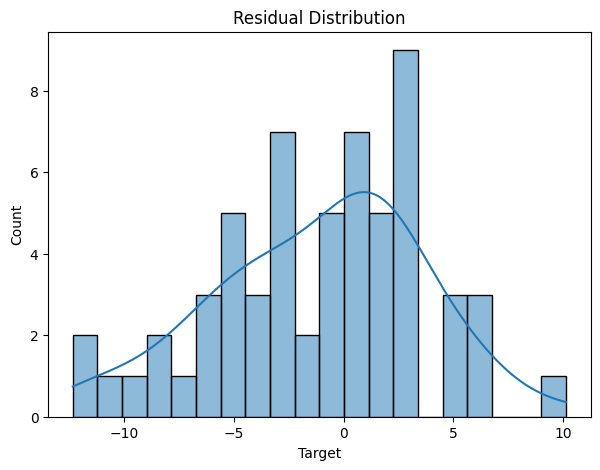

In [71]:
plt.figure(figsize=(7,5))

sns.histplot(
    residuals,
    kde=True,
    bins=20
)

plt.title("Residual Distribution")

plt.show()

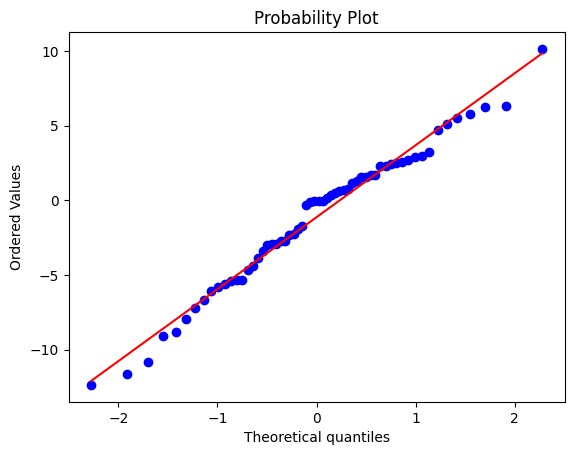

In [72]:
stats.probplot(residuals,dist="norm",plot=plt)

plt.show()

# Homoscedasticity

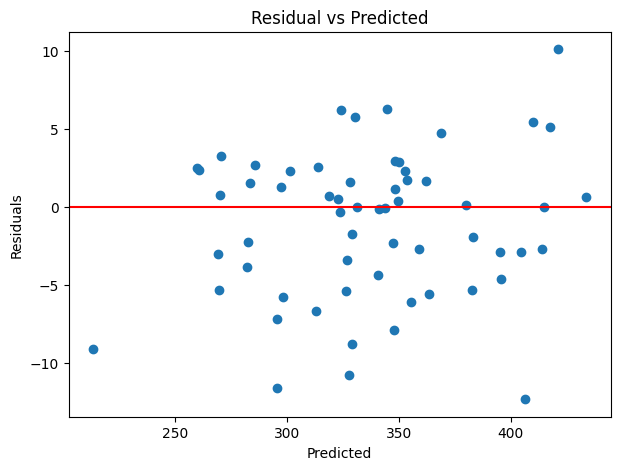

In [73]:
plt.figure(figsize=(7,5))

plt.scatter(y_pred,residuals)

plt.axhline(y=0,color='red')

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.title("Residual vs Predicted")

plt.show()

# No Autocorrelation


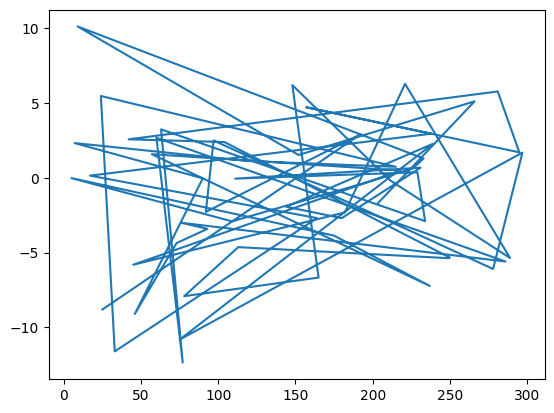

In [75]:
plt.plot(residuals)